In [1]:
using Plots, LinearAlgebra

In [2]:
# Gaussian
function gaussian(x, x0, width, amp)
    return amp * exp.(-(x.-x0).^2 ./ (2*width^2))
end
# Gaussian derivative; positive left, negative right of x0
function gaussian_derivative(x, x0, width, amp)
    return -amp * (x .- x0) ./ width^2 .* exp.(-(x .- x0).^2 ./ (2*width^2))
end
# d/dx
function DfDx(x, f)
    N = length(x)
    dx = x[2] - x[1]
    idx = 1/dx
    f_x = zeros(N)

    # forward FD left
    f_x[1] = idx*(f[2]-f[1])

    # centred FD interior
    for i in 2:N-1
        f_x[i] = 0.5*idx*(f[i+1]-f[i-1])
    end

    # backward FD right
    f_x[N] = idx*(f[end-1]-f[end])

    return f_x
end
# integrate Df/Dx = b -> A f = b -> f = A \ b
function int_DfDx(x, b)
    N = length(x)
    dx = x[2] - x[1]
    idx = 1/dx
    A = zeros(N,N)

    # forward FD left
    #f_x[1] = idx*(f[2]-f[1])
    #A[1,1] = -idx
    #A[1,2] = idx
    A[1,1] = 1.0

    # centred FD interior
    for i in 2:N-1
        #f_x[i] = 0.5*idx*(f[i+1]-f[i-1])
        A[i,i-1] = -0.5*idx
        A[i,i+1] = 0.5*idx
    end

    # backward FD right
    #f_x[N] = idx*(f[end-1]-f[end])
    #A[N,N-1] = idx
    #A[N,N] = -idx
    A[N,N] = 1.0
    return A #/ b
end

int_DfDx (generic function with 1 method)

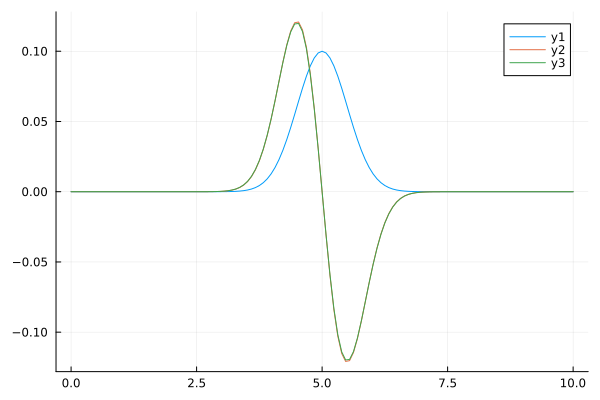

In [3]:
N = 128+1
x = range(0,10,N)

x0 = 5
w = 0.5
A = 0.1

g = gaussian(x, x0, w, A)
g_x_true = gaussian_derivative(x, x0, w, A)
g_x_num = DfDx(x, g)

plot(x,g)
plot!(x, g_x_true)
plot!(x, g_x_num)

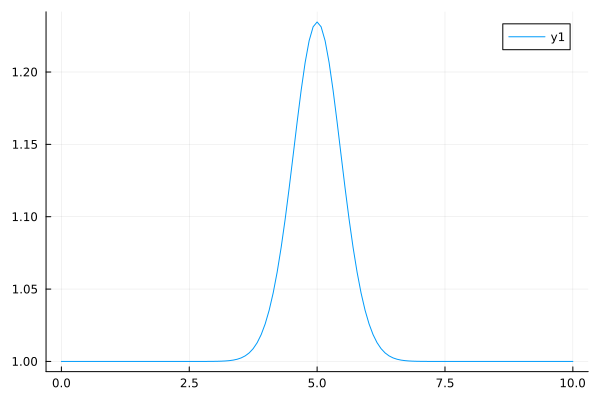

In [4]:
u_x = 1.0./(1.0 .-g).^2
plot(x, u_x)


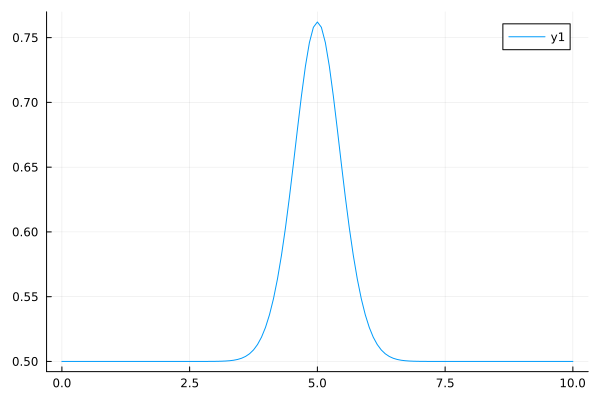

In [5]:
H = 0.5*u_x.^2
plot(x,H)

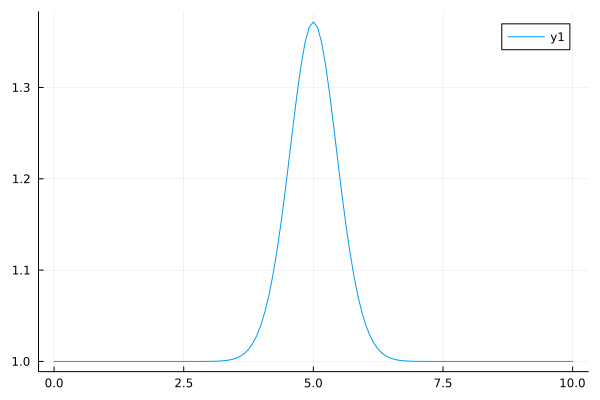

In [6]:
phase_field_rhs = 2*(1 .- g).*H
plot(x,phase_field_rhs)

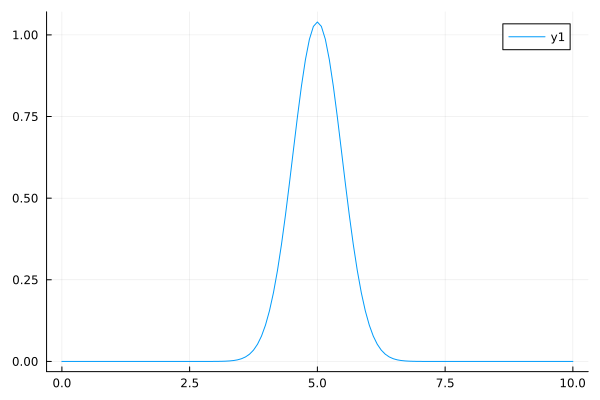

In [7]:
gc = 1.0
l = 0.1

phase_field_lhs = (gc/l)*(g - l^2* DfDx(x,g_x_true))

plot(x, phase_field_lhs)

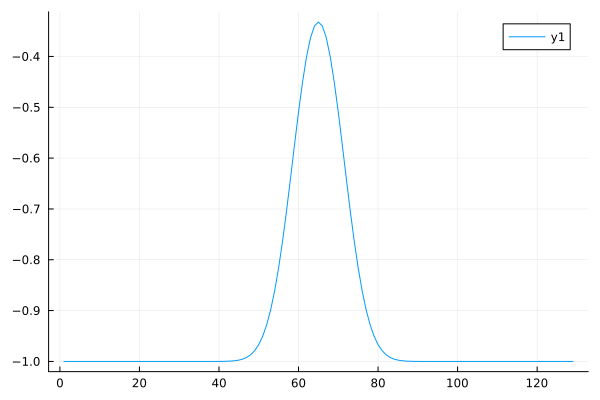

In [8]:
plot(phase_field_lhs.-phase_field_rhs)

In [9]:
d = g

129-element Vector{Float64}:
 1.928749847963918e-23
 9.0899100678901e-23
 4.1806169355170357e-22
 1.876369098120734e-21
 8.21851355409674e-21
 3.512896762713672e-20
 1.4653271804402422e-19
 5.964869290941517e-19
 2.369541747340176e-18
 9.185967516020612e-18
 3.4752220036018666e-17
 1.2830314698448246e-16
 4.622630405483706e-16
 ⋮
 1.2830314698448246e-16
 3.4752220036018666e-17
 9.185967516020612e-18
 2.369541747340176e-18
 5.964869290941517e-19
 1.4653271804402422e-19
 3.512896762713672e-20
 8.21851355409674e-21
 1.876369098120734e-21
 4.1806169355170357e-22
 9.0899100678901e-23
 1.928749847963918e-23

In [10]:
# midpoint
function stagav(f)
    N = length(f)
    f_mid = zeros(N-1)
    for i in 1:N-1
        f_mid[i] = 0.5*(f[i]+f[i+1])
    end
    return f_mid
end

stagav (generic function with 1 method)

In [11]:
    g = (1.0 .- d).^2 .+ 1e-6
    g_mid = stagav(g)

128-element Vector{Float64}:
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.0000009999999997
 1.0000009999999993
 1.000000999999998
 ⋮
 1.0000009999999993
 1.0000009999999997
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001
 1.000001

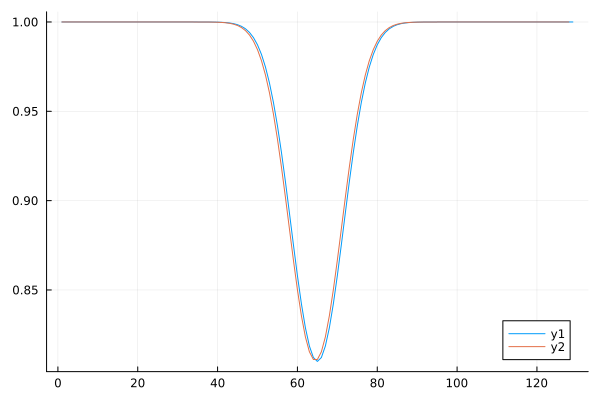

In [12]:
plot(g)
plot!(g_mid)

In [13]:
# Step 3: displacement
N = length(x)
E = 1.0
F = 10.0
dx = x[2] - x[1]
g = (1.0 .- d).^2 .+ 1e-6
g_mid = stagav(g)

A = zeros(N,N)
b = zeros(N)

# Dirichlet left
A[1,1] = 1.0
b[1] = 0.0

idx = 1/dx

for i in 2:N-1
    A[i,i-1] = g_mid[i-1]*E*idx^2
    A[i,i]   = -E*idx^2*(g_mid[i]+g_mid[i-1])
    A[i,i+1] = g_mid[i]*E*idx^2
end

# Neumann right
A[N,N] = 1.0
A[N,N-1] = -1.0
b[N] = 2*F / (E*g[N]) * dx

u = A \ b

129-element Vector{Float64}:
  -2.990839880990544e-12
   1.5624984374984032
   3.1249968749997974
   4.687495312501191
   6.249993750002585
   7.812492187503979
   9.374990625005374
  10.937489062506769
  12.499987500008164
  14.062485937509559
  15.624984375010953
  17.187482812512343
  18.749981250013732
   ⋮
 188.41949031725218
 189.98198875475373
 191.54448719225522
 193.1069856297567
 194.6694840672582
 196.23198250475969
 197.79448094226117
 199.3569793797627
 200.91947781726424
 202.48197625476578
 204.04447469226733
 205.60697312976887

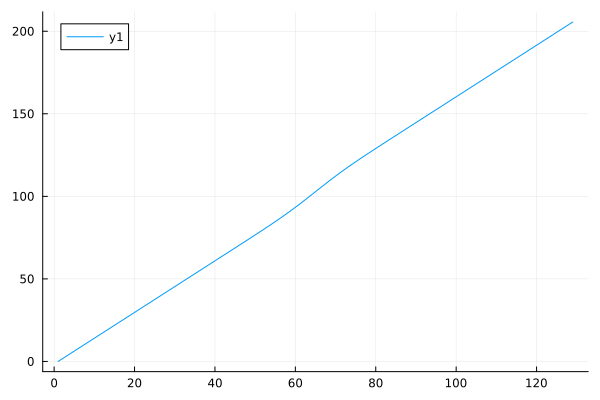

In [14]:
plot(u)

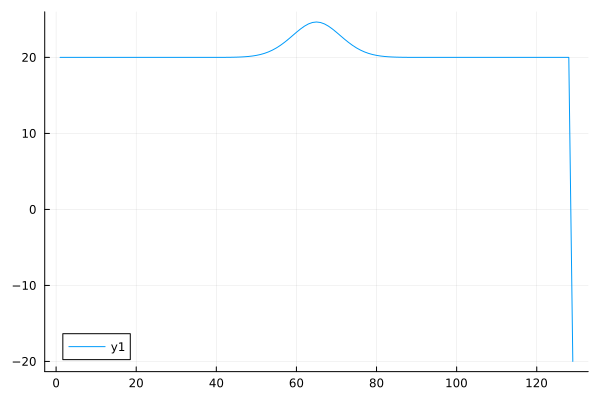

In [15]:
u_x=DfDx(x,u)
plot(u_x)

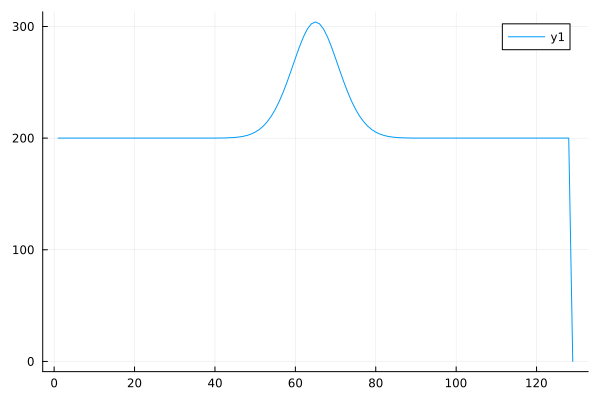

In [16]:
H_new = 0.5*E.*max.(u_x,0).^2
plot(H_new)

In [17]:
# Step 2: phase-field
H = copy(H_new)
l = 0.01
gc = 1
M = zeros(N,N)
f = 2*l*H

for i in 2:N-1
    M[i,i-1] = -l*gc*idx^2
    M[i,i]   = gc/l + 2*l*gc*idx^2 + 2*H[i]
    M[i,i+1] = -l*gc*idx^2
end

# Neumann BC
M[1,1] = gc/l + 2*l*gc*idx^2 + 2*H[1]
M[1,2] = -2*l*gc*idx^2
M[N,N] = gc/l + 2*l*gc*idx^2 + 2*H[N]
M[N,N-1] = -2*l*gc*idx^2

dd = M \ f

129-element Vector{Float64}:
 0.007999996799999336
 0.007999996799999336
 0.007999996799999335
 0.007999996799999335
 0.007999996799999336
 0.007999996799999336
 0.007999996799999336
 0.007999996799999336
 0.007999996799999336
 0.007999996799999336
 0.007999996799999331
 0.007999996799999326
 0.007999996799999326
 ⋮
 0.007999996799999647
 0.00799999679999959
 0.00799999679999953
 0.00799999679999953
 0.00799999679999953
 0.007999996799999522
 0.007999996799996727
 0.007999996799129444
 0.00799999653270709
 0.007999914695200155
 0.007974776501454008
 0.00025302631026488524

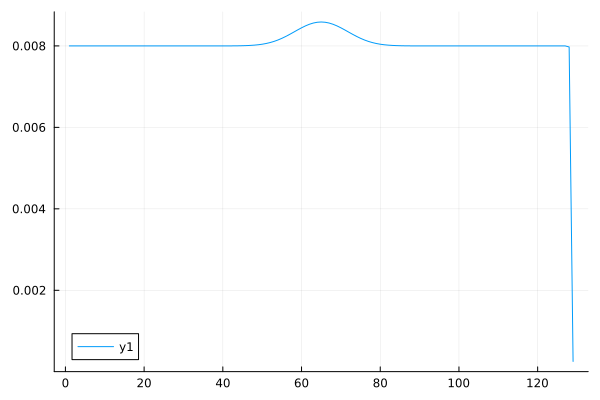

In [18]:
plot(dd)
#plot!(d)

In [19]:
sum(d)

1.6042420957638401

In [20]:
sum(dd)

1.0339512842250806

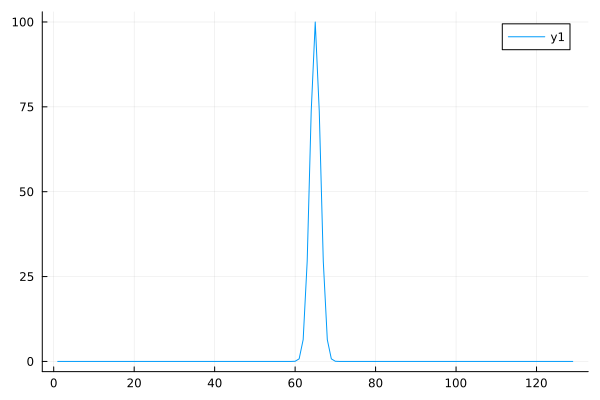

In [21]:
ff = gaussian(x, x[end]/2, 0.1, 100.0)
plot(ff)